<a href="https://colab.research.google.com/github/jiffy-jacob/Sentiment-Analysis/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Sentiment Analysis**
##Objective:  
Develop machine learning models to classify emotions in text samples.

## Dataset:
https://drive.google.com/file/d/1HWczIICsMpaL8EJyu48ZvRFcXx3_pcnb/view?usp=drive_link

#Key components to be fulfilled :
1. Loading and Preprocessing:

● Load the dataset and perform necessary preprocessing steps. This should include text
cleaning, tokenization, and removal of stopwords. Explain the preprocessing techniques
used and their impact on model performance.

2. Feature Extraction :

● Implement feature extraction using CountVectorizer or TfidfVectorizer. Describe how the
chosen method transforms the text data into numerical features.

3. Model Development:

● Train the following machine learning models

a)Naive Bayes

b)Support Vector Machine  

4. Model Comparison

● Evaluate the model using appropriate metrics (e.g., accuracy, F1-score).

Provide a brief
explanation of the chosen model and its suitability for emotion classification.

# **Loading Data and Preprocessing**

In [1]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re          #text cleaning using regular expressions
import string      #handling punctuation

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, f1_score, classification_report

In [2]:
from google.colab import drive
#from google.colab import files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df=pd.read_csv("/content/drive/MyDrive/nlp_dataset.csv")
print(df.shape)
print(df.columns)
print(df.head())
print("Missing values\n")
print(df.isnull().sum())
print(df.info)


(5937, 2)
Index(['Comment', 'Emotion'], dtype='object')
                                             Comment Emotion
0  i seriously hate one subject to death but now ...    fear
1                 im so full of life i feel appalled   anger
2  i sit here to write i start to dig out my feel...    fear
3  ive been really angry with r and i feel like a...     joy
4  i feel suspicious if there is no one outside l...    fear
Missing values

Comment    0
Emotion    0
dtype: int64
<bound method DataFrame.info of                                                 Comment Emotion
0     i seriously hate one subject to death but now ...    fear
1                    im so full of life i feel appalled   anger
2     i sit here to write i start to dig out my feel...    fear
3     ive been really angry with r and i feel like a...     joy
4     i feel suspicious if there is no one outside l...    fear
...                                                 ...     ...
5932                 i begun to feel distre

In [4]:
print("\nEmotion Counts:")
print(df["Emotion"].value_counts())


Emotion Counts:
Emotion
anger    2000
joy      2000
fear     1937
Name: count, dtype: int64


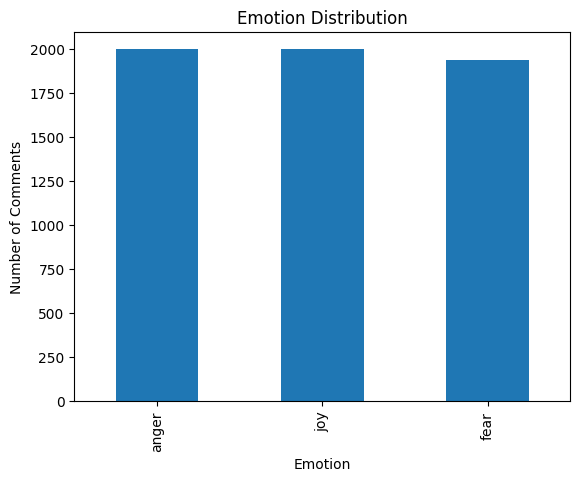

In [5]:
#emotion Distribution
df["Emotion"].value_counts().plot(kind="bar")
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Comments")
plt.show()

In [6]:
pip install nltk

In [7]:
#Text preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [8]:
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Join words back together
    return " ".join(words)

In [9]:
df["clean_comment"]=df["Comment"].apply(preprocess_text)
df.head()

,Comment,Emotion,clean_comment
0,i seriously hate one subject to death but now ...,fear,seriously hate one subject death feel reluctan...
1,im so full of life i feel appalled,anger,im full life feel appalled
2,i sit here to write i start to dig out my feel...,fear,sit write start dig feelings think afraid acce...
3,ive been really angry with r and i feel like a...,joy,ive really angry r feel like idiot trusting fi...
4,i feel suspicious if there is no one outside l...,fear,feel suspicious one outside like rapture happe...


In [10]:
print("Original:")
print(df["Comment"].iloc[0])

print("\nCleaned:")
print(df["clean_comment"].iloc[0])

Original:
i seriously hate one subject to death but now i feel reluctant to drop it

Cleaned:
seriously hate one subject death feel reluctant drop


The punctuation and common stopwords have been removed, while the important emotion-related words such as “hate”, “death”, and “reluctant” remain.

In [11]:
#Train-test-Split
X=df["clean_comment"]
y=df["Emotion"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [12]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4749
Testing samples: 1188


# **TF-IDF Feature Extraction**

In [13]:
vectorizer=TfidfVectorizer(max_features=1000)
X_train_tfidf=vectorizer.fit_transform(X_train)
X_test_tfidf=vectorizer.transform(X_test)


In [14]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4749, 1000)
Testing TF-IDF shape: (1188, 1000)


# **Model Development**

# a) Naive Bayes

In [15]:
nb_model=MultinomialNB()
nb_model.fit(X_train_tfidf,y_train)
y_pred_nb=nb_model.predict(X_test_tfidf)

In [17]:
#model Evaluation
accuracy_nb = accuracy_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb, average="weighted")

print("Naive Bayes Results")
print("Accuracy:", accuracy_nb)
print("F1 Score:", f1_nb)

Naive Bayes Results
Accuracy: 0.8998316498316499
F1 Score: 0.8998287650991615


In [18]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))


Classification Report:
              precision    recall  f1-score   support

       anger       0.89      0.89      0.89       400
        fear       0.89      0.92      0.90       388
         joy       0.92      0.89      0.90       400

    accuracy                           0.90      1188
   macro avg       0.90      0.90      0.90      1188
weighted avg       0.90      0.90      0.90      1188



# b)SVM

In [19]:
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

LinearSVC()

In [20]:
y_pred_svm = svm_model.predict(X_test_tfidf)

In [21]:
#model Evaluation
accuracy_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm, average="weighted")

print("SVM Results")
print("Accuracy:", accuracy_svm)
print("F1 Score:", f1_svm)

SVM Results
Accuracy: 0.9284511784511784
F1 Score: 0.9283909992467408


In [22]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))


Classification Report:
              precision    recall  f1-score   support

       anger       0.94      0.91      0.92       400
        fear       0.93      0.93      0.93       388
         joy       0.91      0.95      0.93       400

    accuracy                           0.93      1188
   macro avg       0.93      0.93      0.93      1188
weighted avg       0.93      0.93      0.93      1188



In [23]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "SVM"],
    "Accuracy": [accuracy_nb, accuracy_svm],
    "F1 Score": [f1_nb, f1_svm]
})

results

,Model,Accuracy,F1 Score
0,Naive Bayes,0.899832,0.899829
1,SVM,0.928451,0.928391


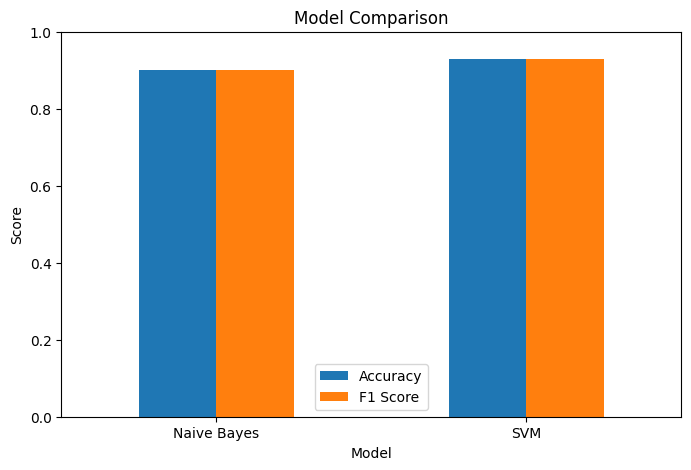

In [24]:
results.set_index("Model")[["Accuracy", "F1 Score"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

#**Conclusion**

In this assignment, text data was preprocessed by converting text to lowercase, removing punctuation and stopwords, and tokenizing the comments. TF-IDF was then used to convert the text into numerical features for machine learning.

Two models, Naive Bayes and Support Vector Machine (SVM), were trained to classify the emotions **anger, fear, and joy**.

Naive Bayes achieved an accuracy of **89.98%** and an F1-score of **89.98%**, while SVM achieved a higher accuracy of **92.85%** and an F1-score of **92.84%**.

Therefore, **SVM performed better than Naive Bayes** for this emotion classification task. Its higher accuracy and F1-score indicate that it was more effective at distinguishing between anger, fear, and joy in the given dataset.


In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


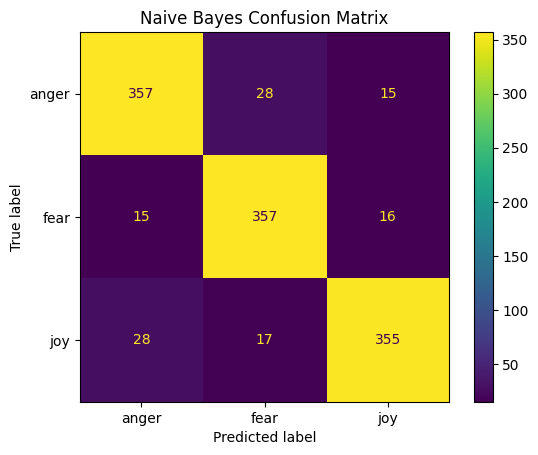

In [30]:
#Naive Bayes confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=nb_model.classes_
)

disp.plot()
plt.title("Naive Bayes Confusion Matrix")
plt.show()

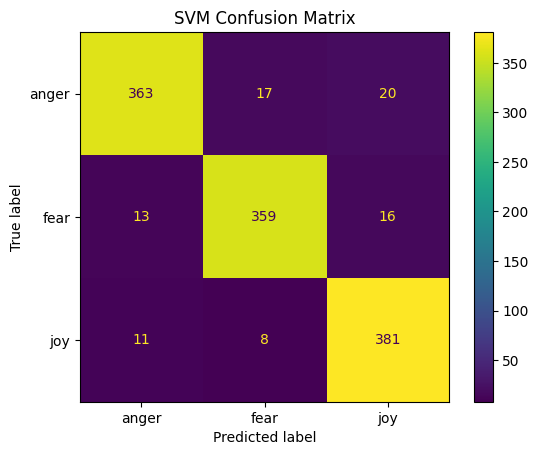

In [31]:
#SVM Confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=svm_model.classes_
)

disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()

Confusion matrix shows most predictions concentrated along the diagonal.

# **Test the Model**

In [25]:
new_comments = [
    "I am extremely happy today",
    "I am very angry with what happened",
    "I am scared and worried about this situation"
]
clean_comments = [preprocess_text(comment) for comment in new_comments]

In [27]:
new_comments_tfidf = vectorizer.transform(clean_comments)

In [28]:
predictions = svm_model.predict(new_comments_tfidf)

for comment, prediction in zip(new_comments, predictions):
    print("Comment:", comment)
    print("Predicted Emotion:", prediction)
    print()

Comment: I am extremely happy today
Predicted Emotion: joy

Comment: I am very angry with what happened
Predicted Emotion: anger

Comment: I am scared and worried about this situation
Predicted Emotion: fear

